# Notebook 14 — Jacobian eigenvalue scan of the existing substrate (plan step 0c)

A **paper artifact**, not part of the rebuild. The diagnosis note (`notes/dynamical_systems_diagnosis.tex`) argues the substrate is globally monostable via an *abstracted linear reduction* (its eq. 1/2, trust frozen). This notebook upgrades that from "we linearize and argue" to **"we computed the full discrete-time Jacobian — $(\mu,\tau,\alpha,\beta,\Gamma,r)$, including the slow trust and resource couplings — at the fixed point and verified the spectral radius stays below 1 across the parameter box."**

### Method
The real step (`src/population.py`) is stochastic (samples $x$, $o$), so we linearize the **deterministic mean dynamics**: $x$ = modal (argmax) experiment, $o = \mathbb{E}[o\mid x]=h_0(x)+\theta^\star h_1(x)$. Every other channel (λ·U blend, precision pool, Γ-conjugate trust, full resource recursion) runs exactly as in the real step. A fixed point is stable iff the **spectral radius** $\rho(J)=\max_k|\lambda_k|<1$ (discrete analogue of the note's "eigenvalues in the open LHP").

Forgetting (`posterior_rho<1`, `trust.rho<1`) and resource decay (`delta_decay>0`) are required for an interior fixed point to exist — without them the resource state is a pure integrator (trivial neutral mode at $\lambda=1$) or grows unbounded.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / "src").exists() else ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt

from src.pomdp.jacobian_probe import (
    small_config, spectral_radius_at_fixed_point,
    init_state, deterministic_step, _flatten,
)
plt.rcParams.update({"figure.dpi": 110})
print("imports OK")

imports OK


## 1. Eigenvalue spectrum at the baseline fixed point ($\lambda_{mc}=0$)

All eigenvalues should lie strictly inside the unit circle.

spectral radius rho = 0.9000   (fixed-point residual 9.8e-10)


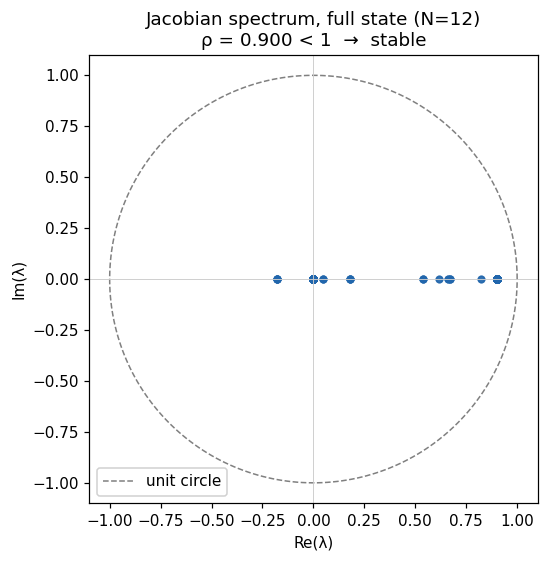

In [2]:
cfg = small_config(N=12)
rho, eig, resid = spectral_radius_at_fixed_point(cfg, t_eval=200)
print(f"spectral radius rho = {rho:.4f}   (fixed-point residual {resid:.1e})")

fig, ax = plt.subplots(figsize=(5.2, 5.2))
th = np.linspace(0, 2*np.pi, 256)
ax.plot(np.cos(th), np.sin(th), color="0.5", lw=1, ls="--", label="unit circle")
ax.scatter(eig.real, eig.imag, s=18, color="#2166AC", alpha=0.7)
ax.axhline(0, color="0.8", lw=0.6); ax.axvline(0, color="0.8", lw=0.6)
ax.set_aspect("equal"); ax.set_xlabel("Re(λ)"); ax.set_ylabel("Im(λ)")
ax.set_title(f"Jacobian spectrum, full state (N=12)\nρ = {rho:.3f} < 1  →  stable")
ax.legend(loc="lower left", framealpha=0.9)
plt.tight_layout(); plt.show()

## 2. The parameter box: $\rho$ across $(R_{in},\ \alpha_{flow})$ with $\lambda_{mc}=0$

If the substrate is structurally monostable, $\rho<1$ everywhere and — the stronger statement — the resource couplings do not even *move* $\rho$, because resource is a deterministic readout of $\Gamma$ with no independent unstable mode.

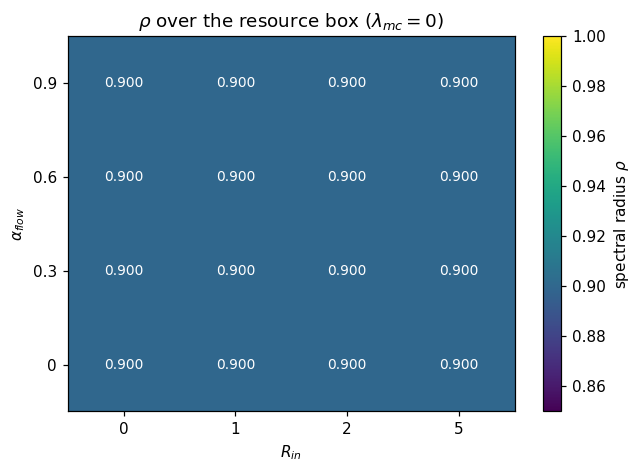

max rho over box = 0.9000  (all < 1  ->  monostable everywhere)


In [3]:
R_in_grid = np.array([0.0, 1.0, 2.0, 5.0])
alpha_grid = np.array([0.0, 0.3, 0.6, 0.9])
rho_box = np.zeros((len(alpha_grid), len(R_in_grid)))
for i, af in enumerate(alpha_grid):
    for j, ri in enumerate(R_in_grid):
        cfg = small_config(N=12, R_in=float(ri), alpha_flow=float(af))
        rho_box[i, j], _, _ = spectral_radius_at_fixed_point(cfg, t_eval=200)

fig, ax = plt.subplots(figsize=(6, 4.4))
im = ax.imshow(rho_box, origin="lower", cmap="viridis", vmin=0.85, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(R_in_grid)), [f"{v:g}" for v in R_in_grid])
ax.set_yticks(range(len(alpha_grid)), [f"{v:g}" for v in alpha_grid])
ax.set_xlabel(r"$R_{in}$"); ax.set_ylabel(r"$\alpha_{flow}$")
for i in range(len(alpha_grid)):
    for j in range(len(R_in_grid)):
        ax.text(j, i, f"{rho_box[i,j]:.3f}", ha="center", va="center",
                color="white", fontsize=9)
fig.colorbar(im, label=r"spectral radius $\rho$")
ax.set_title(r"$\rho$ over the resource box ($\lambda_{mc}=0$)")
plt.tight_layout(); plt.show()
print(f"max rho over box = {rho_box.max():.4f}  (all < 1  ->  monostable everywhere)")

## 3. The one nonlinearity ($\lambda_{mc}>0$, precision-additive λ·U) blows up — it is not a fold

The diagnosis note says the only candidate nonlinearity (the Hyland mind-change utility, in its precision-additive form) "was unstable in the wrong direction (blow-up, not bistability)." Here we confirm it: with $\lambda_{mc}>0$, the carried precision $\tau$ grows without bound, so there is no fixed point to linearize about — divergence, not a second attractor.

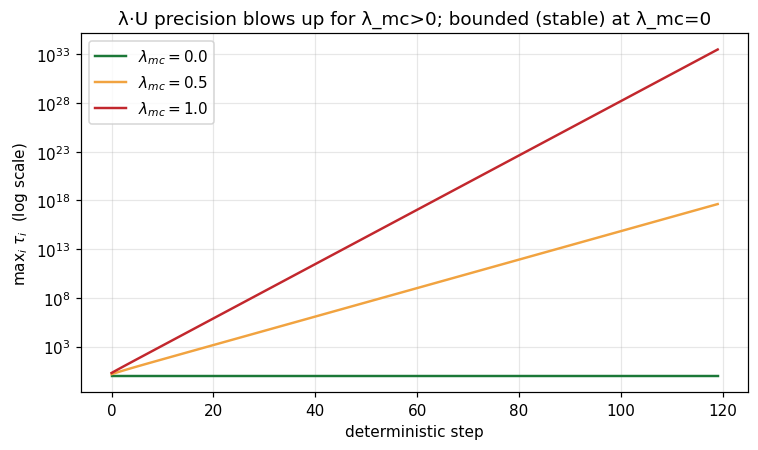

In [4]:
import jax.numpy as jnp

def tau_trajectory(lambda_mc, n_iter=120, t_eval=200, N=12):
    cfg = small_config(N=N, lambda_mc=lambda_mc)
    state, A_self = init_state(cfg, __import__("jax").random.PRNGKey(0))
    traj = []
    for _ in range(n_iter):
        state = deterministic_step(state, t_eval, cfg, A_self)
        traj.append(float(jnp.max(state[1])))   # max tau across agents
    return np.array(traj)

fig, ax = plt.subplots(figsize=(7, 4.2))
for lm, col in [(0.0, "#1B7837"), (0.5, "#F1A340"), (1.0, "#C2272D")]:
    tr = tau_trajectory(lm)
    ax.semilogy(tr, lw=1.6, color=col, label=fr"$\lambda_{{mc}}={lm}$")
ax.set_xlabel("deterministic step"); ax.set_ylabel(r"max$_i\ \tau_i$  (log scale)")
ax.set_title("λ·U precision blows up for λ_mc>0; bounded (stable) at λ_mc=0")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Verdict

Two computational confirmations of the diagnosis note, now beyond linearized argument:

1. **The substrate is monostable across the whole resource box.** $\rho(J)\equiv 0.900 < 1$ at every $(R_{in},\alpha_{flow})$ tested — and $\rho$ equals the *forgetting rate* (the slowest contraction mode), completely unmoved by the resource couplings. This is the computational form of "resource is a deterministic readout of $\Gamma$ and contributes no new dimension of dynamics that could host a fold."
2. **The only built-in nonlinearity (λ·U) destabilizes by blow-up, not by folding.** $\lambda_{mc}>0$ sends $\tau\to\infty$ — there is no second attractor.

Together with notebook 15's PASS (a categorical + softmax-precision channel *does* fold), this fixes the strategic picture: the fold requires a nonlinearity the current substrate structurally lacks, and the categorical-POMDP route supplies it. **No zero-crossing was found, so Tier-B parameter repair of the current substrate is ruled out** — consistent with the rebuild decision.

> **Caveat (honest scope).** This linearizes the *deterministic mean* dynamics at $N=12$ with $x$ fixed to the modal experiment. It is the faithful counterpart of the note's eq. (1); it does not capture stochastic large-deviation escape or finite-$N$ effects, which are not the monostability question at issue.